# PERSUADE Corpus - Memory Curve Analysis

Compute memory curves (context dependency) for PERSUADE 2.0 essays.

**Experiments:**
1. **Score comparison**: low (1-2) vs mid (3-4) vs high (5-6)
2. **Grade trajectory**: grades 6, 9, 12
3. **ELL comparison**: ELL vs non-ELL
4. **Prompt effects**: top 6 prompts

**Key metric:** Half-life = context length to achieve 50% of total perplexity benefit

In [1]:
# Install dependencies
!pip install -q torch transformers accelerate bitsandbytes pandas numpy matplotlib seaborn tqdm statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 11.6 MB/s eta 0:00:00


In [2]:
import json
import math
import os
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.8 GB


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ============================================================
# CONFIGURATION
# ============================================================

# Paths on Drive
DRIVE_BASE = "/content/drive/MyDrive/LRTIA/Data/persuade_clean"
OUTPUT_BASE = "/content/drive/MyDrive/LRTIA/Results/Persuade"
COHORTS_DIR = f"{DRIVE_BASE}/cohorts"

# Cohort files
COHORTS = {
    'score': f"{COHORTS_DIR}/persuade_score_cohort.jsonl",
    'grade': f"{COHORTS_DIR}/persuade_grade_cohort.jsonl",
    'ell': f"{COHORTS_DIR}/persuade_ell_cohort.jsonl",
    'prompt': f"{COHORTS_DIR}/persuade_prompt_cohort.jsonl",
}

# Model
MODEL_NAME = "mistralai/Mistral-7B-v0.1"

# ============================================================
# THREE-REGIME WINDOW CONFIGURATION
# ============================================================
# Scoring parameters (shared)
MAX_SCORE_TOKENS = 256
BUFFER = 10

# SHORT regime: smallest windows, all essays
WINDOWS_SHORT = [32, 64, 128]
BURN_IN_SHORT = 128
SHORT_MIN_TOKENS = BURN_IN_SHORT + MAX_SCORE_TOKENS + BUFFER  # = 394

# MAIN regime: adds medium windows
WINDOWS_MAIN = [32, 64, 128, 256, 384]
BURN_IN_MAIN = 384
MAIN_MIN_TOKENS = BURN_IN_MAIN + MAX_SCORE_TOKENS + BUFFER    # = 650

# EXTENDED regime: adds largest window
WINDOWS_EXT = WINDOWS_MAIN + [512]
BURN_IN_EXT = 512
EXT_MIN_TOKENS = BURN_IN_EXT + MAX_SCORE_TOKENS + BUFFER      # = 778

# All windows for output columns
WINDOWS_ALL = [32, 64, 128, 256, 384, 512]

# GPU settings
USE_4BIT = True  # False for A100, True for T4/V100

# Experiment to run
EXPERIMENT = 'score'  # Options: 'score', 'grade', 'ell', 'prompt'

print(f"Experiment: {EXPERIMENT}")
print(f"Data: {DRIVE_BASE}")
print(f"Results: {OUTPUT_BASE}")
print(f"\n{'='*60}")
print("THREE-REGIME CONFIGURATION")
print(f"{'='*60}")
print(f"\nSHORT regime (essays >= {SHORT_MIN_TOKENS} tokens):")
print(f"  Windows: {WINDOWS_SHORT}, Burn-in: {BURN_IN_SHORT}")
print(f"\nMAIN regime (essays >= {MAIN_MIN_TOKENS} tokens):")
print(f"  Windows: {WINDOWS_MAIN}, Burn-in: {BURN_IN_MAIN}")
print(f"\nEXTENDED regime (essays >= {EXT_MIN_TOKENS} tokens):")
print(f"  Windows: {WINDOWS_EXT}, Burn-in: {BURN_IN_EXT}")
print(f"\nEssays < {SHORT_MIN_TOKENS} tokens will be SKIPPED")
print(f"\nPrimary analysis: windows {WINDOWS_SHORT} (all essays)")
print(f"Secondary analysis: windows [256, 384] (main+ essays)")
print(f"Tertiary analysis: window [512] (extended essays only)")

Experiment: score
Data: /content/drive/MyDrive/LRTIA/Data/persuade_clean
Results: /content/drive/MyDrive/LRTIA/Results/Persuade

THREE-REGIME CONFIGURATION

SHORT regime (essays >= 394 tokens):
  Windows: [32, 64, 128], Burn-in: 128

MAIN regime (essays >= 650 tokens):
  Windows: [32, 64, 128, 256, 384], Burn-in: 384

EXTENDED regime (essays >= 778 tokens):
  Windows: [32, 64, 128, 256, 384, 512], Burn-in: 512

Essays < 394 tokens will be SKIPPED

Primary analysis: windows [32, 64, 128] (all essays)
Secondary analysis: windows [256, 384] (main+ essays)
Tertiary analysis: window [512] (extended essays only)


In [5]:
# ============================================================
# QUICK TEST: Verify Drive paths
# ============================================================

print("Checking Drive paths...\n")

# Check data directory
if os.path.exists(DRIVE_BASE):
    print(f"✓ DRIVE_BASE exists: {DRIVE_BASE}")
    print(f"  Contents: {os.listdir(DRIVE_BASE)}")
else:
    print(f"✗ DRIVE_BASE NOT FOUND: {DRIVE_BASE}")

# Check cohorts
if os.path.exists(COHORTS_DIR):
    print(f"\n✓ Cohorts dir: {os.listdir(COHORTS_DIR)}")
else:
    print(f"\n✗ Cohorts dir NOT FOUND: {COHORTS_DIR}")

# Check each file
print("\nCohort files:")
for name, path in COHORTS.items():
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"  ✓ {name}: {size:,} bytes")
    else:
        print(f"  ✗ {name}: NOT FOUND")

# Quick load test
print("\n" + "="*50)
print("Quick load test:")
try:
    with open(COHORTS['score'], 'r') as f:
        record = json.loads(f.readline())
    print(f"✓ Loaded first record: essay_id={record.get('essay_id')}, score={record.get('score')}")
    print(f"  token_count={record.get('token_count')} (need >= {BURN_IN_MAIN + MAX_SCORE_TOKENS} for main regime)")
except Exception as e:
    print(f"✗ Failed: {e}")

Checking Drive paths...

✓ DRIVE_BASE exists: /content/drive/MyDrive/LRTIA/Data/persuade_clean
  Contents: ['persuade_clean.jsonl', 'persuade_ingest_report.txt', 'persuade_clean.csv', 'persuade_250w.jsonl', '.DS_Store', 'cohorts']

✓ Cohorts dir: ['persuade_ell_cohort.jsonl', 'persuade_prompt_cohort.jsonl', 'persuade_prompt_essay_ids.txt', 'persuade_grade_essay_ids.txt', 'persuade_ell_essay_ids.txt', 'persuade_grade_cohort.jsonl', 'persuade_score_cohort.jsonl', 'persuade_score_essay_ids.txt']

Cohort files:
  ✓ score: 1,343,249 bytes
  ✓ grade: 1,188,805 bytes
  ✓ ell: 857,484 bytes
  ✓ prompt: 2,861,117 bytes

Quick load test:
✓ Loaded first record: essay_id=2BB4BFD96ABE, score=1
  token_count=425 (need >= 640 for main regime)


## 2. Load Model

In [6]:
# Load tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Loading tokenizer: mistralai/Mistral-7B-v0.1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [7]:
# Load model
print(f"Loading model: {MODEL_NAME}")

if USE_4BIT:
    print("  Using 4-bit quantization")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb_config, device_map="auto"
    )
else:
    print("  Using float16 (A100 mode)")
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
    )

model.eval()
print("Model loaded")

Loading model: mistralai/Mistral-7B-v0.1
  Using 4-bit quantization


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded


## 3. Core Functions

In [8]:
def load_cohort(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records

@torch.no_grad()
def compute_perplexity_on_region(token_ids, target_start, target_end):
    """Compute perplexity on tokens[target_start:target_end]."""
    if target_end > len(token_ids):
        target_end = len(token_ids)
    if target_start >= target_end - 1:
        return float('inf'), 0

    input_ids = torch.tensor([token_ids], device=model.device)
    outputs = model(input_ids)
    logits = outputs.logits[0]

    total_loss = 0.0
    count = 0
    for i in range(target_start, target_end - 1):
        log_probs = torch.log_softmax(logits[i], dim=-1)
        token_loss = -log_probs[token_ids[i + 1]].item()
        total_loss += token_loss
        count += 1

    return math.exp(total_loss / count) if count > 0 else float('inf'), count

def compute_memory_curve_from_tokens(token_ids, windows, burn_in, max_score_tokens):
    """
    Compute memory curve from pre-tokenized input.

    Args:
        token_ids: List of token IDs (already tokenized)
        windows: List of context window sizes to test
        burn_in: Number of tokens to skip before scoring region
        max_score_tokens: Maximum tokens to score after burn_in

    Returns:
        dict with ppl_by_W, computed_windows, token_count, target_tokens
    """
    result = {'ppl_by_W': {}, 'computed_windows': [], 'token_count': len(token_ids), 'target_tokens': 0}

    n_tokens = len(token_ids)

    # Check if essay is long enough
    if n_tokens <= burn_in:
        return result

    # Define scoring region: [burn_in, burn_in + max_score_tokens)
    target_end = min(n_tokens, burn_in + max_score_tokens)
    result['target_tokens'] = target_end - burn_in

    for W in windows:
        # Context starts W tokens before burn_in (or at 0)
        context_start = max(0, burn_in - W)
        actual_context = burn_in - context_start

        if actual_context < 4:  # Need at least 4 tokens of context
            continue

        # Extract [context_start : target_end]
        truncated = token_ids[context_start:target_end]

        # Score on [actual_context : len(truncated)]
        ppl, _ = compute_perplexity_on_region(truncated, actual_context, len(truncated))

        if not math.isinf(ppl):
            result['ppl_by_W'][W] = ppl
            result['computed_windows'].append(W)

    return result

def compute_half_life(ppl_by_W, percentile=0.5):
    """Compute half-life: context length to achieve percentile of total benefit."""
    if len(ppl_by_W) < 2:
        return float('nan')

    items = sorted(ppl_by_W.items())
    windows = np.array([x[0] for x in items])
    ppls = np.array([x[1] for x in items])

    total_benefit = ppls[0] - ppls[-1]  # Short context - long context
    if total_benefit <= 0:
        return float('nan')

    target_ppl = ppls[0] - percentile * total_benefit

    # Interpolate to find window where we hit target
    for i in range(len(ppls) - 1):
        if ppls[i] >= target_ppl >= ppls[i + 1]:
            frac = (ppls[i] - target_ppl) / (ppls[i] - ppls[i + 1])
            return windows[i] + frac * (windows[i + 1] - windows[i])

    return windows[-1]

def compute_half_life_on_windows(ppl_by_W, target_windows, percentile=0.5):
    """
    Compute half-life using only specified windows (for cross-regime comparability).

    Args:
        ppl_by_W: dict of {window: perplexity}
        target_windows: list of windows to use (e.g., [32, 64, 128])
        percentile: fraction of benefit for half-life (default 0.5)

    Returns:
        half-life value or NaN if insufficient data
    """
    # Filter to target windows
    filtered = {w: ppl for w, ppl in ppl_by_W.items() if w in target_windows}
    return compute_half_life(filtered, percentile)

def compute_curve_features(ppl_by_W):
    """Extract features from a memory curve (using all available windows)."""
    features = {
        'half_life': float('nan'),      # Full half-life (regime-specific max window)
        'half_life_128': float('nan'),  # Comparable half-life (max window = 128)
        'delta_max': float('nan'),
        'delta_128': float('nan'),      # Benefit up to W=128 only
    }
    if len(ppl_by_W) < 2:
        return features

    items = sorted(ppl_by_W.items())
    features['delta_max'] = items[0][1] - items[-1][1]  # Total benefit (all windows)
    features['half_life'] = compute_half_life(ppl_by_W, 0.5)

    # Comparable metrics using only WINDOWS_SHORT [32, 64, 128]
    features['half_life_128'] = compute_half_life_on_windows(ppl_by_W, [32, 64, 128], 0.5)

    # Delta up to 128 only
    ppl_32 = ppl_by_W.get(32)
    ppl_128 = ppl_by_W.get(128)
    if ppl_32 is not None and ppl_128 is not None:
        features['delta_128'] = ppl_32 - ppl_128

    return features

print("Functions defined")
print("  - half_life: uses all available windows (regime-specific)")
print("  - half_life_128: uses only [32,64,128] (comparable across regimes)")

Functions defined
  - half_life: uses all available windows (regime-specific)
  - half_life_128: uses only [32,64,128] (comparable across regimes)


## 4. Load and Process Cohort

In [9]:
# Load cohort
cohort = load_cohort(COHORTS[EXPERIMENT])
print(f"Loaded {len(cohort)} essays for {EXPERIMENT} experiment")

# Preview
df_cohort = pd.DataFrame(cohort)
print(f"\nCohort summary:")
if 'score' in df_cohort.columns:
    print(df_cohort['score'].value_counts().sort_index())

Loaded 450 essays for score experiment

Cohort summary:
score
1     45
2    105
3     61
4     89
5    129
6     21
Name: count, dtype: int64


In [10]:
# Process all essays with three-regime approach
results = []
start_time = time.time()
regime_counts = {'short': 0, 'main': 0, 'extended': 0, 'skipped': 0}
skipped_ids = []

for essay in tqdm(cohort, desc="Processing"):
    # Tokenize once
    token_ids = tokenizer.encode(essay['text'], add_special_tokens=False)
    n_tokens = len(token_ids)

    # Skip essays that are too short
    if n_tokens < SHORT_MIN_TOKENS:
        regime_counts['skipped'] += 1
        skipped_ids.append(essay.get('essay_id'))
        continue

    # Determine regime and parameters
    if n_tokens >= EXT_MIN_TOKENS:
        regime = 'extended'
        windows = WINDOWS_EXT
        burn_in = BURN_IN_EXT
        regime_counts['extended'] += 1
    elif n_tokens >= MAIN_MIN_TOKENS:
        regime = 'main'
        windows = WINDOWS_MAIN
        burn_in = BURN_IN_MAIN
        regime_counts['main'] += 1
    else:
        regime = 'short'
        windows = WINDOWS_SHORT
        burn_in = BURN_IN_SHORT
        regime_counts['short'] += 1

    # Compute memory curve
    curve = compute_memory_curve_from_tokens(token_ids, windows, burn_in, MAX_SCORE_TOKENS)
    features = compute_curve_features(curve['ppl_by_W'])

    # Build result row
    result = {
        'essay_id': essay.get('essay_id'),
        'score': essay.get('score'),
        'grade': essay.get('grade'),
        'ell': essay.get('ell'),
        'prompt_id': essay.get('prompt_id'),
        'word_count': essay.get('word_count'),
        'token_count': n_tokens,
        'regime': regime,
        'burn_in_used': burn_in,
        **features,
    }

    # Add perplexity columns for ALL windows (NaN if not computed)
    for W in WINDOWS_ALL:
        result[f'ppl_W{W}'] = curve['ppl_by_W'].get(W, float('nan'))

    results.append(result)

elapsed = time.time() - start_time
n_processed = len(results)
print(f"\nDone in {elapsed:.1f}s ({elapsed/max(1,n_processed):.2f}s/essay)")
print(f"\nRegime breakdown (of {len(cohort)} total essays):")
print(f"  SHORT ({BURN_IN_SHORT} burn-in):    {regime_counts['short']:3} ({100*regime_counts['short']/len(cohort):.1f}%)")
print(f"  MAIN ({BURN_IN_MAIN} burn-in):     {regime_counts['main']:3} ({100*regime_counts['main']/len(cohort):.1f}%)")
print(f"  EXTENDED ({BURN_IN_EXT} burn-in): {regime_counts['extended']:3} ({100*regime_counts['extended']/len(cohort):.1f}%)")
print(f"  Skipped (< {SHORT_MIN_TOKENS} tokens): {regime_counts['skipped']:3} ({100*regime_counts['skipped']/len(cohort):.1f}%)")
if regime_counts['skipped'] > 0:
    print(f"\n  Skipped IDs: {skipped_ids[:5]}{'...' if len(skipped_ids) > 5 else ''}")

Processing:   0%|          | 0/450 [00:00<?, ?it/s]


Done in 926.6s (2.06s/essay)

Regime breakdown (of 450 total essays):
  SHORT (128 burn-in):    295 (65.6%)
  MAIN (384 burn-in):      80 (17.8%)
  EXTENDED (512 burn-in):  75 (16.7%)
  Skipped (< 394 tokens):   0 (0.0%)


In [11]:
# Convert to DataFrame and add score_bin
df_results = pd.DataFrame(results)
if 'score' in df_results.columns:
    df_results['score_bin'] = df_results['score'].apply(
        lambda x: 'low' if x <= 2 else ('mid' if x <= 4 else 'high') if pd.notna(x) else 'unk'
    )

# Set up grouping
if EXPERIMENT == 'score':
    GROUP_VAR, GROUP_ORDER = 'score_bin', ['low', 'mid', 'high']
elif EXPERIMENT == 'grade':
    GROUP_VAR, GROUP_ORDER = 'grade', sorted(df_results['grade'].dropna().unique())
elif EXPERIMENT == 'ell':
    GROUP_VAR, GROUP_ORDER = 'ell', ['ELL', 'non_ELL']
else:
    GROUP_VAR, GROUP_ORDER = 'prompt_id', df_results['prompt_id'].value_counts().index.tolist()

print(f"Grouping by: {GROUP_VAR}")
print(f"Groups: {GROUP_ORDER}")

Grouping by: score_bin
Groups: ['low', 'mid', 'high']


## 5. Results

In [12]:
# Group summary with regime breakdown and selection effects
print("="*70)
print(f"GROUP SUMMARY ({GROUP_VAR})")
print("="*70)

# Overall summary using COMPARABLE half_life_128 (PRIMARY)
summary_rows = []
for group in GROUP_ORDER:
    g_df = df_results[df_results[GROUP_VAR] == group]
    if len(g_df) == 0:
        continue
    row = {
        'group': group,
        'n': len(g_df),
        # PRIMARY metrics (comparable across regimes)
        'half_life_128_mean': g_df['half_life_128'].mean(),
        'half_life_128_sem': g_df['half_life_128'].sem(),
        'delta_128_mean': g_df['delta_128'].mean(),
        # SECONDARY metrics (regime-specific)
        'half_life_full_mean': g_df['half_life'].mean(),
        'delta_max_mean': g_df['delta_max'].mean(),
    }
    summary_rows.append(row)
    print(f"\n{group}: n={row['n']}")
    print(f"  PRIMARY (comparable):")
    print(f"    half_life_128: {row['half_life_128_mean']:.1f} ± {row['half_life_128_sem']:.1f}")
    print(f"    delta_128:     {row['delta_128_mean']:.2f}")
    print(f"  SECONDARY (regime-specific):")
    print(f"    half_life_full: {row['half_life_full_mean']:.1f}")
    print(f"    delta_max:      {row['delta_max_mean']:.2f}")

df_summary = pd.DataFrame(summary_rows)

# ============================================================
# GROUP × REGIME CROSSTAB WITH SELECTION EFFECTS
# ============================================================
print("\n" + "="*70)
print("GROUP × REGIME CROSSTAB (Selection Effects)")
print("="*70)
print("\nCounts:")
print(f"{'Group':<15} {'SHORT':>10} {'MAIN':>10} {'EXT':>10} {'Total':>10}")
print("-"*55)
for group in GROUP_ORDER:
    g_df = df_results[df_results[GROUP_VAR] == group]
    n_short = len(g_df[g_df['regime'] == 'short'])
    n_main = len(g_df[g_df['regime'] == 'main'])
    n_ext = len(g_df[g_df['regime'] == 'extended'])
    print(f"{str(group):<15} {n_short:>10} {n_main:>10} {n_ext:>10} {len(g_df):>10}")

print("\nMedian token count per cell:")
print(f"{'Group':<15} {'SHORT':>10} {'MAIN':>10} {'EXT':>10} {'Overall':>10}")
print("-"*55)
for group in GROUP_ORDER:
    g_df = df_results[df_results[GROUP_VAR] == group]
    med_short = g_df[g_df['regime'] == 'short']['token_count'].median()
    med_main = g_df[g_df['regime'] == 'main']['token_count'].median()
    med_ext = g_df[g_df['regime'] == 'extended']['token_count'].median()
    med_all = g_df['token_count'].median()

    short_str = f"{med_short:.0f}" if not pd.isna(med_short) else "-"
    main_str = f"{med_main:.0f}" if not pd.isna(med_main) else "-"
    ext_str = f"{med_ext:.0f}" if not pd.isna(med_ext) else "-"
    print(f"{str(group):<15} {short_str:>10} {main_str:>10} {ext_str:>10} {med_all:>10.0f}")

# ============================================================
# PER-GROUP WINDOW COVERAGE (Selection Explicit)
# ============================================================
print("\n" + "="*70)
print("PER-GROUP WINDOW COVERAGE (non-NaN counts)")
print("="*70)
print(f"\n{'Group':<15}", end="")
for W in WINDOWS_ALL:
    print(f"{'W='+str(W):>10}", end="")
print(f"{'Total':>10}")
print("-"*75)

for group in GROUP_ORDER:
    g_df = df_results[df_results[GROUP_VAR] == group]
    print(f"{str(group):<15}", end="")
    for W in WINDOWS_ALL:
        n_valid = g_df[f'ppl_W{W}'].notna().sum()
        print(f"{n_valid:>10}", end="")
    print(f"{len(g_df):>10}")

print(f"\n{'Group':<15}", end="")
for W in WINDOWS_ALL:
    print(f"{'W='+str(W):>10}", end="")
print()
print("-"*65)
print("Percentage with valid window:")
for group in GROUP_ORDER:
    g_df = df_results[df_results[GROUP_VAR] == group]
    n_total = len(g_df)
    print(f"{str(group):<15}", end="")
    for W in WINDOWS_ALL:
        n_valid = g_df[f'ppl_W{W}'].notna().sum()
        pct = 100 * n_valid / n_total if n_total > 0 else 0
        print(f"{pct:>9.0f}%", end="")
    print()

# Overall window coverage
print("\n" + "="*70)
print("OVERALL WINDOW COVERAGE")
print("="*70)
for W in WINDOWS_ALL:
    col = f'ppl_W{W}'
    n_valid = df_results[col].notna().sum()
    pct = 100 * n_valid / len(df_results)
    status = "PRIMARY" if W <= 128 else "SECONDARY" if W <= 384 else "TERTIARY"
    print(f"  W={W:3}: {n_valid:4} essays ({pct:5.1f}%) [{status}]")

df_summary

GROUP SUMMARY (score_bin)

low: n=150
  PRIMARY (comparable):
    half_life_128: 69.8 ± 1.3
    delta_128:     1.93
  SECONDARY (regime-specific):
    half_life_full: 78.7
    delta_max:      2.12

mid: n=150
  PRIMARY (comparable):
    half_life_128: 70.7 ± 1.2
    delta_128:     1.41
  SECONDARY (regime-specific):
    half_life_full: 82.0
    delta_max:      1.60

high: n=150
  PRIMARY (comparable):
    half_life_128: 70.6 ± 1.2
    delta_128:     1.21
  SECONDARY (regime-specific):
    half_life_full: 138.6
    delta_max:      2.18

GROUP × REGIME CROSSTAB (Selection Effects)

Counts:
Group                SHORT       MAIN        EXT      Total
-------------------------------------------------------
low                    133         11          6        150
mid                    127         14          9        150
high                    35         55         60        150

Median token count per cell:
Group                SHORT       MAIN        EXT    Overall
-------------------

,group,n,half_life_128_mean,half_life_128_sem,delta_128_mean,half_life_full_mean,delta_max_mean
0,low,150,69.783686,1.251155,1.929955,78.721531,2.124861
1,mid,150,70.731595,1.198931,1.405124,81.954007,1.604360
2,high,150,70.596645,1.229373,1.211310,138.564140,2.177676


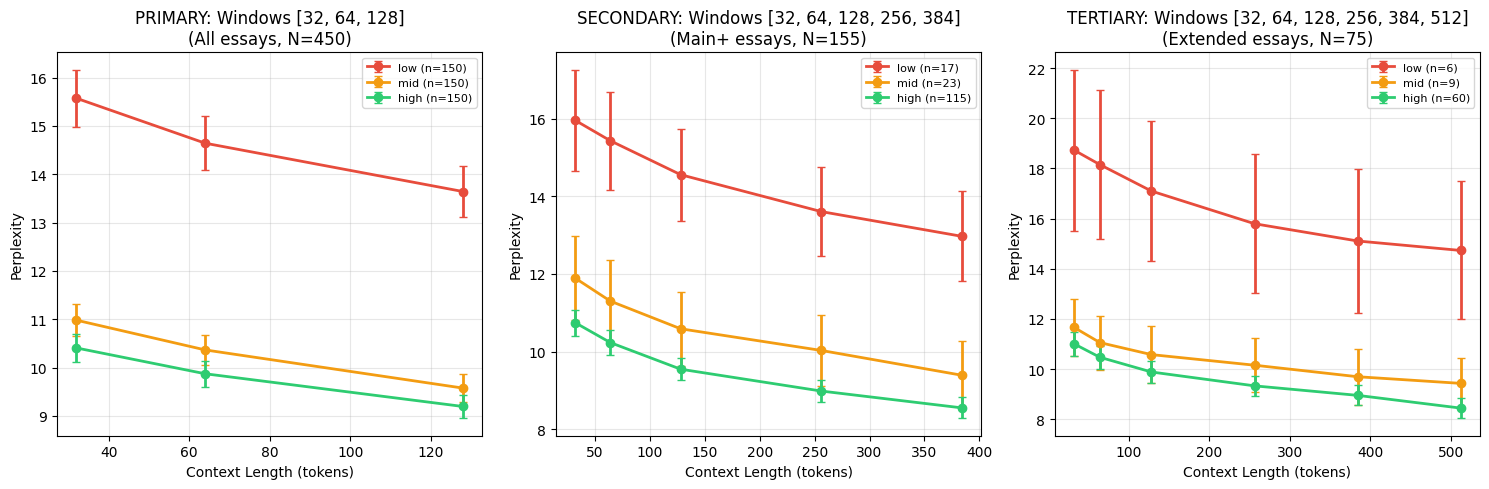

In [13]:
# Plot memory curves - PRIMARY ANALYSIS (windows 32, 64, 128 - all essays)
COLORS = {
    'score': {'low': '#e74c3c', 'mid': '#f39c12', 'high': '#2ecc71'},
    'grade': {6: '#3498db', 9: '#9b59b6', 12: '#e74c3c'},
    'ell': {'ELL': '#e74c3c', 'non_ELL': '#2ecc71'},
}
colors = COLORS.get(EXPERIMENT, {})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Primary windows (all essays)
ax1 = axes[0]
for group in GROUP_ORDER:
    g_df = df_results[df_results[GROUP_VAR] == group]
    if len(g_df) == 0:
        continue
    means = [g_df[f'ppl_W{W}'].mean() for W in WINDOWS_SHORT]
    sems = [g_df[f'ppl_W{W}'].sem() for W in WINDOWS_SHORT]
    color = colors.get(group)
    ax1.errorbar(WINDOWS_SHORT, means, yerr=sems, marker='o', capsize=3,
                label=f"{group} (n={len(g_df)})", color=color, linewidth=2)
ax1.set_xlabel('Context Length (tokens)')
ax1.set_ylabel('Perplexity')
ax1.set_title(f'PRIMARY: Windows {WINDOWS_SHORT}\n(All essays, N={len(df_results)})')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Main+ windows (main and extended essays only)
ax2 = axes[1]
df_main_plus = df_results[df_results['regime'].isin(['main', 'extended'])]
for group in GROUP_ORDER:
    g_df = df_main_plus[df_main_plus[GROUP_VAR] == group]
    if len(g_df) == 0:
        continue
    means = [g_df[f'ppl_W{W}'].mean() for W in WINDOWS_MAIN]
    sems = [g_df[f'ppl_W{W}'].sem() for W in WINDOWS_MAIN]
    color = colors.get(group)
    ax2.errorbar(WINDOWS_MAIN, means, yerr=sems, marker='o', capsize=3,
                label=f"{group} (n={len(g_df)})", color=color, linewidth=2)
ax2.set_xlabel('Context Length (tokens)')
ax2.set_ylabel('Perplexity')
ax2.set_title(f'SECONDARY: Windows {WINDOWS_MAIN}\n(Main+ essays, N={len(df_main_plus)})')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Extended only
ax3 = axes[2]
df_ext = df_results[df_results['regime'] == 'extended']
for group in GROUP_ORDER:
    g_df = df_ext[df_ext[GROUP_VAR] == group]
    if len(g_df) < 2:
        continue
    means = [g_df[f'ppl_W{W}'].mean() for W in WINDOWS_EXT]
    sems = [g_df[f'ppl_W{W}'].sem() for W in WINDOWS_EXT]
    color = colors.get(group)
    ax3.errorbar(WINDOWS_EXT, means, yerr=sems, marker='o', capsize=3,
                label=f"{group} (n={len(g_df)})", color=color, linewidth=2)
ax3.set_xlabel('Context Length (tokens)')
ax3.set_ylabel('Perplexity')
ax3.set_title(f'TERTIARY: Windows {WINDOWS_EXT}\n(Extended essays, N={len(df_ext)})')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Statistical tests using COMPARABLE half_life_128
from scipy import stats

print("="*70)
print("STATISTICAL TESTS (using half_life_128 - comparable across regimes)")
print("="*70)

print("\nPairwise t-tests on half_life_128:")
for i, g1 in enumerate(GROUP_ORDER):
    for g2 in GROUP_ORDER[i+1:]:
        v1 = df_results[df_results[GROUP_VAR] == g1]['half_life_128'].dropna()
        v2 = df_results[df_results[GROUP_VAR] == g2]['half_life_128'].dropna()
        if len(v1) >= 2 and len(v2) >= 2:
            t, p = stats.ttest_ind(v1, v2)
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            print(f"  {g1} vs {g2}: t={t:.2f}, p={p:.4f} {sig}")

print("\n" + "-"*50)
print("(For reference) Pairwise t-tests on half_life_full (regime-specific):")
for i, g1 in enumerate(GROUP_ORDER):
    for g2 in GROUP_ORDER[i+1:]:
        v1 = df_results[df_results[GROUP_VAR] == g1]['half_life'].dropna()
        v2 = df_results[df_results[GROUP_VAR] == g2]['half_life'].dropna()
        if len(v1) >= 2 and len(v2) >= 2:
            t, p = stats.ttest_ind(v1, v2)
            sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            print(f"  {g1} vs {g2}: t={t:.2f}, p={p:.4f} {sig}")

STATISTICAL TESTS (using half_life_128 - comparable across regimes)

Pairwise t-tests on half_life_128:
  low vs mid: t=-0.55, p=0.5848 
  low vs high: t=-0.46, p=0.6434 
  mid vs high: t=0.08, p=0.9374 

--------------------------------------------------
(For reference) Pairwise t-tests on half_life_full (regime-specific):
  low vs mid: t=-0.72, p=0.4710 
  low vs high: t=-8.20, p=0.0000 ***
  mid vs high: t=-7.72, p=0.0000 ***


## 5b. Length Covariate Analysis

Control for essay length when comparing groups (addresses length confounding).

In [15]:
# Length covariate regression using COMPARABLE half_life_128
import statsmodels.formula.api as smf

print("="*70)
print("LENGTH & REGIME COVARIATE ANALYSIS")
print("="*70)
print("\nUsing half_life_128 (comparable across regimes, max window = 128)")

# Prepare data (drop NaN half_life_128)
df_reg = df_results.dropna(subset=['half_life_128', 'token_count']).copy()

# Standardize token_count for interpretability
df_reg['token_count_z'] = (df_reg['token_count'] - df_reg['token_count'].mean()) / df_reg['token_count'].std()

# Set regime as categorical with 'short' as reference
df_reg['regime'] = pd.Categorical(df_reg['regime'], categories=['short', 'main', 'extended'], ordered=True)

print(f"\nRegression on {len(df_reg)} essays with valid half_life_128")

# Run regression based on experiment type
if EXPERIMENT == 'score':
    df_reg['score_bin'] = pd.Categorical(df_reg['score_bin'], categories=['low', 'mid', 'high'], ordered=True)
    formula_base = 'half_life_128 ~ C(score_bin) + token_count_z'
    formula_regime = 'half_life_128 ~ C(score_bin) + token_count_z + C(regime)'

elif EXPERIMENT == 'prompt':
    formula_base = 'half_life_128 ~ C(prompt_id) + token_count_z'
    formula_regime = 'half_life_128 ~ C(prompt_id) + token_count_z + C(regime)'

elif EXPERIMENT == 'grade':
    formula_base = 'half_life_128 ~ C(grade) + token_count_z'
    formula_regime = 'half_life_128 ~ C(grade) + token_count_z + C(regime)'

elif EXPERIMENT == 'ell':
    df_reg['ell'] = pd.Categorical(df_reg['ell'], categories=['ELL', 'non_ELL'])
    formula_base = 'half_life_128 ~ C(ell) + token_count_z'
    formula_regime = 'half_life_128 ~ C(ell) + token_count_z + C(regime)'

# Model 1: Without regime
print(f"\n{'='*70}")
print("MODEL 1: group + length (without regime)")
print(f"{'='*70}")
print(f"Formula: {formula_base}")
ols_base = smf.ols(formula_base, data=df_reg).fit()
print(ols_base.summary().tables[1])
print(f"\nR-squared: {ols_base.rsquared:.3f}")

# Model 2: With regime
print(f"\n{'='*70}")
print("MODEL 2: group + length + regime")
print(f"{'='*70}")
print(f"Formula: {formula_regime}")
ols_model = smf.ols(formula_regime, data=df_reg).fit()
print(ols_model.summary().tables[1])
print(f"\nR-squared: {ols_model.rsquared:.3f}")

# Key findings
print(f"\n{'='*70}")
print("KEY FINDINGS (Model 2)")
print(f"{'='*70}")
print(f"\nLength effect (per 1 SD): {ols_model.params.get('token_count_z', 0):.2f} tokens half-life")

print(f"\nGroup effects (controlling for length + regime):")
for param, coef in ols_model.params.items():
    if 'C(' in param and 'token' not in param and 'regime' not in param:
        pval = ols_model.pvalues[param]
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        print(f"  {param}: {coef:+.2f} {sig} (p={pval:.4f})")

print(f"\nRegime effects (vs short):")
for param, coef in ols_model.params.items():
    if 'regime' in param:
        pval = ols_model.pvalues[param]
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        print(f"  {param}: {coef:+.2f} {sig} (p={pval:.4f})")

# Store for saving
formula = formula_regime

LENGTH & REGIME COVARIATE ANALYSIS

Using half_life_128 (comparable across regimes, max window = 128)

Regression on 450 essays with valid half_life_128

MODEL 1: group + length (without regime)
Formula: half_life_128 ~ C(score_bin) + token_count_z
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               70.1342      1.366     51.348      0.000      67.450      72.819
C(score_bin)[T.mid]      0.7623      1.765      0.432      0.666      -2.706       4.231
C(score_bin)[T.high]    -0.0530      2.281     -0.023      0.981      -4.536       4.430
token_count_z            0.5580      0.953      0.585      0.559      -1.316       2.432

R-squared: 0.002

MODEL 2: group + length + regime
Formula: half_life_128 ~ C(score_bin) + token_count_z + C(regime)
                            coef    std err          t      P>|t|      [0.025      0.975]
---------

## 5c. Robustness Check: Length-Matched Subsample

Bin essays by token_count deciles, sample equal counts per group within each bin, then recompute group means.

In [16]:
# Robustness check: Length-matched subsampling using half_life_128
print("="*70)
print("ROBUSTNESS CHECK: LENGTH-MATCHED SUBSAMPLE")
print("="*70)
print("\nUsing half_life_128 (comparable across regimes)")

df_valid = df_results.dropna(subset=['half_life_128', 'token_count']).copy()

# Create token_count decile bins
df_valid['length_bin'] = pd.qcut(df_valid['token_count'], q=10, labels=False, duplicates='drop')

print(f"\nLength bins (deciles):")
for b in sorted(df_valid['length_bin'].unique()):
    bin_df = df_valid[df_valid['length_bin'] == b]
    print(f"  Bin {b}: {bin_df['token_count'].min():.0f}-{bin_df['token_count'].max():.0f} tokens (n={len(bin_df)})")

# Within each bin, find minimum group count and subsample
matched_indices = []
np.random.seed(42)

for length_bin in df_valid['length_bin'].unique():
    bin_df = df_valid[df_valid['length_bin'] == length_bin]

    # Count per group in this bin
    counts = bin_df.groupby(GROUP_VAR).size()
    if len(counts) < len(GROUP_ORDER):
        continue  # Skip bins where not all groups are present

    min_count = counts.min()
    if min_count == 0:
        continue

    # Sample min_count from each group
    for group in GROUP_ORDER:
        group_in_bin = bin_df[bin_df[GROUP_VAR] == group]
        if len(group_in_bin) >= min_count:
            sampled = group_in_bin.sample(n=min_count, random_state=42)
            matched_indices.extend(sampled.index.tolist())

df_matched = df_valid.loc[matched_indices].copy()

print(f"\nLength-matched subsample: {len(df_matched)} essays")
print(f"\nGroup counts (matched):")
for group in GROUP_ORDER:
    g_df = df_matched[df_matched[GROUP_VAR] == group]
    print(f"  {group}: n={len(g_df)}, median_tokens={g_df['token_count'].median():.0f}")

# Compute matched group means
print("\n" + "="*70)
print("MATCHED SUBSAMPLE RESULTS (half_life_128)")
print("="*70)

matched_summary = []
for group in GROUP_ORDER:
    g_df = df_matched[df_matched[GROUP_VAR] == group]
    if len(g_df) == 0:
        continue
    row = {
        'group': group,
        'n': len(g_df),
        'half_life_128_mean': g_df['half_life_128'].mean(),
        'half_life_128_sem': g_df['half_life_128'].sem(),
        'half_life_128_ci95': 1.96 * g_df['half_life_128'].sem(),
    }
    matched_summary.append(row)
    print(f"{group}: half_life_128 = {row['half_life_128_mean']:.1f} ± {row['half_life_128_ci95']:.1f} (95% CI)")

# Compare original vs matched
print("\n" + "="*70)
print("COMPARISON: ORIGINAL vs LENGTH-MATCHED")
print("="*70)
print(f"{'Group':<15} {'Original':>15} {'Matched':>15} {'Diff':>10}")
print("-"*55)

for i, group in enumerate(GROUP_ORDER):
    orig = df_summary[df_summary['group'] == group]
    if len(orig) == 0:
        continue
    orig_hl = orig['half_life_128_mean'].values[0]

    match = [r for r in matched_summary if r['group'] == group]
    if match:
        match_hl = match[0]['half_life_128_mean']
        diff = match_hl - orig_hl
        print(f"{group:<15} {orig_hl:>15.1f} {match_hl:>15.1f} {diff:>+10.1f}")

# Save matched summary
df_matched_summary = pd.DataFrame(matched_summary)

ROBUSTNESS CHECK: LENGTH-MATCHED SUBSAMPLE

Using half_life_128 (comparable across regimes)

Length bins (deciles):
  Bin 0: 401-425 tokens (n=45)
  Bin 1: 427-451 tokens (n=45)
  Bin 2: 452-490 tokens (n=45)
  Bin 3: 491-540 tokens (n=47)
  Bin 4: 542-580 tokens (n=44)
  Bin 5: 581-615 tokens (n=44)
  Bin 6: 616-679 tokens (n=45)
  Bin 7: 680-744 tokens (n=46)
  Bin 8: 745-846 tokens (n=44)
  Bin 9: 849-995 tokens (n=45)

Length-matched subsample: 138 essays

Group counts (matched):
  low: n=46, median_tokens=608
  mid: n=46, median_tokens=614
  high: n=46, median_tokens=612

MATCHED SUBSAMPLE RESULTS (half_life_128)
low: half_life_128 = 70.6 ± 4.6 (95% CI)
mid: half_life_128 = 71.1 ± 4.7 (95% CI)
high: half_life_128 = 68.5 ± 3.9 (95% CI)

COMPARISON: ORIGINAL vs LENGTH-MATCHED
Group                  Original         Matched       Diff
-------------------------------------------------------
low                        69.8            70.6       +0.8
mid                        70.7     

## 6. Save Results

In [17]:
# Save all results
output_dir = Path(f"{OUTPUT_BASE}/{EXPERIMENT}")
output_dir.mkdir(parents=True, exist_ok=True)

# Core results
df_results.to_csv(output_dir / 'essay_level_results.csv', index=False)
df_summary.to_csv(output_dir / 'group_summary.csv', index=False)

# Length-matched subsample results
df_matched_summary.to_csv(output_dir / 'group_summary_length_matched.csv', index=False)
df_matched.to_csv(output_dir / 'essay_level_results_length_matched.csv', index=False)

# Regression results
with open(output_dir / 'regression_summary.txt', 'w') as f:
    f.write(f"Formula: {formula}\n\n")
    f.write(ols_model.summary().as_text())

# Save figure
fig.savefig(output_dir / 'memory_curves.png', dpi=150, bbox_inches='tight')

print(f"\nSaved to {output_dir}/")
print(f"  - essay_level_results.csv ({len(df_results)} essays)")
print(f"  - group_summary.csv")
print(f"  - group_summary_length_matched.csv")
print(f"  - essay_level_results_length_matched.csv ({len(df_matched)} essays)")
print(f"  - regression_summary.txt")
print(f"  - memory_curves.png")


Saved to /content/drive/MyDrive/LRTIA/Results/Persuade/score/
  - essay_level_results.csv (450 essays)
  - group_summary.csv
  - group_summary_length_matched.csv
  - essay_level_results_length_matched.csv (138 essays)
  - regression_summary.txt
  - memory_curves.png
